In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('../visualizations', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')

DB_PATH = '../../statcast-database/statcast-database/data/statcast_2026.db'
conn = sqlite3.connect(DB_PATH)

pitches = pd.read_sql_query("""
    SELECT p.*, g.jays_starter, g.jays_home_away
    FROM pitches p
    JOIN games g ON p.game_date = g.game_date
    WHERE (p.home_team = 'TOR' AND p.inning_topbot = 'Top')
       OR (p.away_team = 'TOR' AND p.inning_topbot = 'Bot')
""", conn)

conn.close()

print("Total pitches loaded: " + str(len(pitches)))
print("Games: " + str(pitches['game_date'].nunique()))
print("Pitchers: " + str(pitches['pitcher_name'].nunique()))

Total pitches loaded: 7958
Games: 54
Pitchers: 24


In [2]:
bullpen = pitches[pitches['pitcher_name'] != pitches['jays_starter']].copy()
print("Bullpen pitches: " + str(len(bullpen)))

appearances = bullpen.groupby(['game_date', 'pitcher_name']).agg(
    total_pitches=('pitch_type', 'count'),
    strikeouts=('events', lambda x: (x == 'strikeout').sum()),
    walks=('events', lambda x: x.isin(['walk', 'hit_by_pitch']).sum()),
    hits=('events', lambda x: x.isin(['single', 'double', 'triple', 'home_run']).sum()),
    hrs=('events', lambda x: (x == 'home_run').sum()),
    whiffs=('description', lambda x: x.isin(['swinging_strike', 'swinging_strike_blocked']).sum()),
    total_swings=('description', lambda x: x.isin(['swinging_strike', 'swinging_strike_blocked',
                   'foul', 'foul_tip', 'hit_into_play', 'hit_into_play_no_out', 'hit_into_play_score']).sum()),
    called_strikes=('description', lambda x: (x == 'called_strike').sum()),
    avg_velo=('release_speed', 'mean'),
    max_velo=('release_speed', 'max'),
    avg_spin=('release_spin_rate', 'mean'),
    avg_ev_against=('launch_speed', 'mean'),
    total_rv=('delta_run_exp', 'sum'),
    n_pitch_types=('pitch_type', 'nunique'),
    innings_pitched=('inning', 'nunique')
).reset_index()

appearances['whiff_rate'] = (appearances['whiffs'] / appearances['total_swings'] * 100).fillna(0)
appearances['csw_rate'] = ((appearances['whiffs'] + appearances['called_strikes']) / appearances['total_pitches'] * 100)
appearances['k_rate'] = (appearances['strikeouts'] / appearances['total_pitches'] * 100)
appearances['bb_rate'] = (appearances['walks'] / appearances['total_pitches'] * 100)
appearances['hr_rate'] = (appearances['hrs'] / appearances['total_pitches'] * 100)

appearances['good_outing'] = ((appearances['hits'] <= 1) &
                               (appearances['hrs'] == 0) &
                               (appearances['walks'] <= 1) &
                               (appearances['total_rv'] <= 0.5)).astype(int)

print("Total appearances: " + str(len(appearances)))
print("Good outings: " + str(appearances['good_outing'].sum()) + " (" + str(round(appearances['good_outing'].mean()*100, 1)) + "%)")
print("Bad outings: " + str((1 - appearances['good_outing']).sum()) + " (" + str(round((1-appearances['good_outing']).mean()*100, 1)) + "%)")

Bullpen pitches: 3695
Total appearances: 202
Good outings: 137 (67.8%)
Bad outings: 65 (32.2%)


In [4]:
appearances = appearances.sort_values(['pitcher_name', 'game_date']).reset_index(drop=True)

for pitcher in appearances['pitcher_name'].unique():
    mask = appearances['pitcher_name'] == pitcher
    idx = appearances[mask].index

    appearances.loc[idx, 'prev_pitches'] = appearances.loc[idx, 'total_pitches'].shift(1)
    appearances.loc[idx, 'prev_whiff_rate'] = appearances.loc[idx, 'whiff_rate'].shift(1)
    appearances.loc[idx, 'prev_velo'] = appearances.loc[idx, 'avg_velo'].shift(1)
    appearances.loc[idx, 'prev_rv'] = appearances.loc[idx, 'total_rv'].shift(1)
    appearances.loc[idx, 'prev_good'] = appearances.loc[idx, 'good_outing'].shift(1)
    appearances.loc[idx, 'prev_k_rate'] = appearances.loc[idx, 'k_rate'].shift(1)

    appearances.loc[idx, 'rolling3_whiff'] = appearances.loc[idx, 'whiff_rate'].shift(1).rolling(3, min_periods=1).mean()
    appearances.loc[idx, 'rolling3_rv'] = appearances.loc[idx, 'total_rv'].shift(1).rolling(3, min_periods=1).mean()
    appearances.loc[idx, 'rolling3_velo'] = appearances.loc[idx, 'avg_velo'].shift(1).rolling(3, min_periods=1).mean()
    appearances.loc[idx, 'rolling3_pitches'] = appearances.loc[idx, 'total_pitches'].shift(1).rolling(3, min_periods=1).mean()
    appearances.loc[idx, 'rolling3_good_pct'] = appearances.loc[idx, 'good_outing'].shift(1).rolling(3, min_periods=1).mean()

    dates = appearances.loc[idx, 'game_date'].values
    rest_days = [0]
    for i in range(1, len(dates)):
        d1 = pd.to_datetime(dates[i-1])
        d2 = pd.to_datetime(dates[i])
        rest_days.append((d2 - d1).days)
    appearances.loc[idx, 'rest_days'] = rest_days

    appearances.loc[idx, 'appearance_num'] = range(1, mask.sum() + 1)

print("Rolling features engineered.")
print("Shape: " + str(appearances.shape))

Rolling features engineered.
Shape: (202, 36)


In [5]:
FEATURES = [
    'total_pitches', 'rest_days', 'appearance_num',
    'prev_pitches', 'prev_whiff_rate', 'prev_velo', 'prev_rv', 'prev_good', 'prev_k_rate',
    'rolling3_whiff', 'rolling3_rv', 'rolling3_velo', 'rolling3_pitches', 'rolling3_good_pct',
    'n_pitch_types'
]

TARGET = 'good_outing'

model_data = appearances.dropna(subset=FEATURES + [TARGET]).copy()
print("Model data: " + str(len(model_data)) + " appearances")
print("Good: " + str(model_data[TARGET].sum()) + " | Bad: " + str((1-model_data[TARGET]).sum()))

X = model_data[FEATURES]
y = model_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

results = {}

for name, model in models.items():
    print("\n" + "=" * 50)
    print("  " + name)
    print("=" * 50)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    baseline = max(y.mean(), 1 - y.mean())
    try:
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = 0.0

    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    print("  Accuracy: " + str(round(accuracy * 100, 1)) + "%")
    print("  Baseline: " + str(round(baseline * 100, 1)) + "%")
    print("  AUC: " + str(round(auc, 3)))
    print("  5-Fold CV: " + str(round(cv_scores.mean() * 100, 1)) + "% (±" + str(round(cv_scores.std() * 100, 1)) + "%)")
    print("\n" + classification_report(y_test, y_pred, target_names=['Bad Outing', 'Good Outing']))

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'baseline': baseline,
        'auc': auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

Model data: 184 appearances
Good: 128 | Bad: 56

  Random Forest
  Accuracy: 62.2%
  Baseline: 69.6%
  AUC: 0.643
  5-Fold CV: 66.3% (±5.2%)

              precision    recall  f1-score   support

  Bad Outing       0.29      0.18      0.22        11
 Good Outing       0.70      0.81      0.75        26

    accuracy                           0.62        37
   macro avg       0.49      0.49      0.49        37
weighted avg       0.58      0.62      0.59        37


  Gradient Boosting
  Accuracy: 73.0%
  Baseline: 69.6%
  AUC: 0.713
  5-Fold CV: 60.3% (±7.8%)

              precision    recall  f1-score   support

  Bad Outing       0.60      0.27      0.38        11
 Good Outing       0.75      0.92      0.83        26

    accuracy                           0.73        37
   macro avg       0.68      0.60      0.60        37
weighted avg       0.71      0.73      0.69        37


  Logistic Regression
  Accuracy: 73.0%
  Baseline: 69.6%
  AUC: 0.692
  5-Fold CV: 68.9% (±7.4%)

      

Best model: Gradient Boosting (AUC: 0.713)
Chart saved!


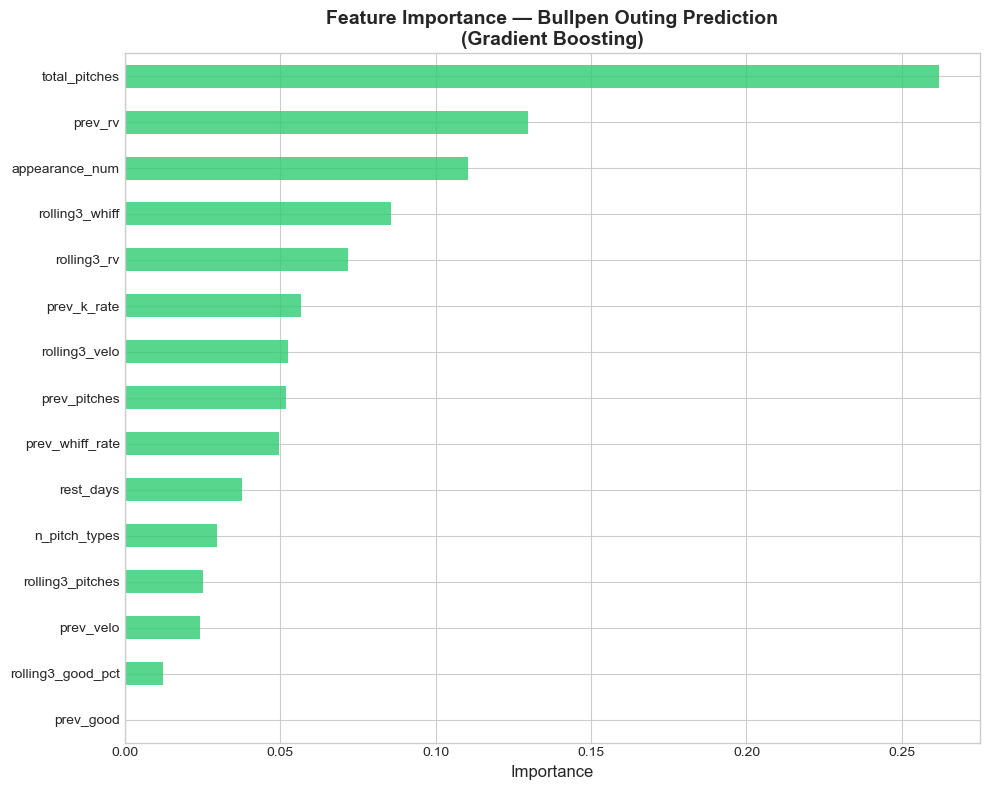

In [6]:
best_model_name = max(results, key=lambda k: results[k]['auc'])
best_model = results[best_model_name]['model']
print("Best model: " + best_model_name + " (AUC: " + str(round(results[best_model_name]['auc'], 3)) + ")")

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = np.zeros(len(FEATURES))

feature_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
feature_imp.plot(kind='barh', ax=ax, color='#2ecc71', alpha=0.8)
ax.set_title('Feature Importance — Bullpen Outing Prediction\n(' + best_model_name + ')', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizations/feature_importance_bullpen.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

In [7]:
print("=== PER-PITCHER PREDICTION ANALYSIS ===\n")

model_data_copy = model_data.copy()
model_data_copy['predicted'] = best_model.predict(model_data_copy[FEATURES])
model_data_copy['predicted_proba'] = best_model.predict_proba(model_data_copy[FEATURES])[:, 1]

pitcher_stats = model_data_copy.groupby('pitcher_name').agg(
    appearances=('good_outing', 'count'),
    good_pct=('good_outing', 'mean'),
    avg_predicted_proba=('predicted_proba', 'mean'),
    correct=('good_outing', lambda x: (model_data_copy.loc[x.index, 'predicted'] == x).sum()),
).reset_index()

pitcher_stats['accuracy'] = (pitcher_stats['correct'] / pitcher_stats['appearances'] * 100).round(1)
pitcher_stats['good_pct'] = (pitcher_stats['good_pct'] * 100).round(1)
pitcher_stats['avg_predicted_proba'] = (pitcher_stats['avg_predicted_proba'] * 100).round(1)
pitcher_stats = pitcher_stats.sort_values('appearances', ascending=False)

print(pitcher_stats[pitcher_stats['appearances'] >= 5][['pitcher_name', 'appearances', 'good_pct', 'avg_predicted_proba', 'accuracy']].to_string(index=False))

=== PER-PITCHER PREDICTION ANALYSIS ===

   pitcher_name  appearances  good_pct  avg_predicted_proba  accuracy
Fluharty, Mason           25      80.0                 87.8      92.0
Fisher, Braydon           24      75.0                 72.7     100.0
  Hoffman, Jeff           24      62.5                 67.8      91.7
  Rogers, Tyler           24      79.2                 78.6     100.0
 Varland, Louis           24      79.2                 78.5      91.7
   Nance, Tommy           19      73.7                 78.9      94.7
  Mantiply, Joe           16      68.8                 73.4      93.8
 Miles, Spencer           12      33.3                 28.7      91.7


Chart saved!


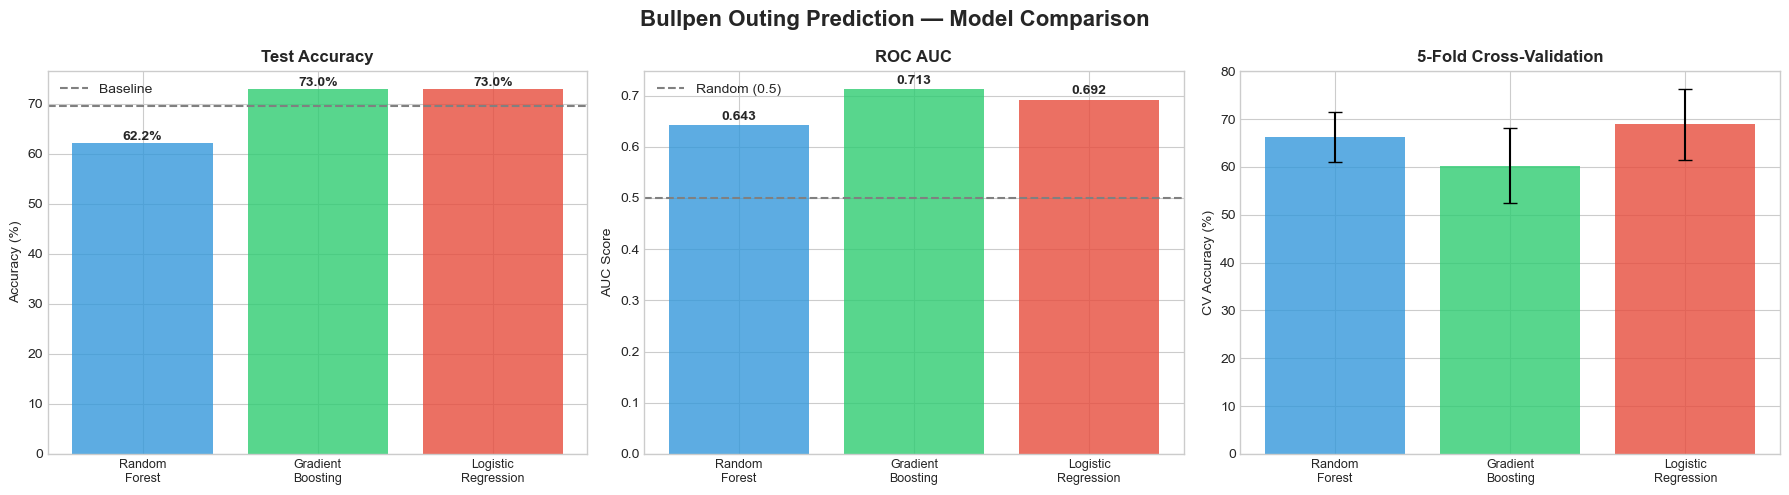

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = list(results.keys())
accuracies = [results[m]['accuracy'] * 100 for m in model_names]
aucs = [results[m]['auc'] for m in model_names]
cv_means = [results[m]['cv_mean'] * 100 for m in model_names]
cv_stds = [results[m]['cv_std'] * 100 for m in model_names]

colors = ['#3498db', '#2ecc71', '#e74c3c']

ax1 = axes[0]
bars = ax1.bar(range(len(model_names)), accuracies, color=colors, alpha=0.8)
ax1.axhline(y=results[model_names[0]]['baseline'] * 100, color='gray', linestyle='--', label='Baseline')
ax1.set_xticks(range(len(model_names)))
ax1.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Test Accuracy', fontweight='bold')
ax1.legend()
for bar, val in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(round(val, 1)) + '%', ha='center', fontweight='bold', fontsize=10)

ax2 = axes[1]
bars = ax2.bar(range(len(model_names)), aucs, color=colors, alpha=0.8)
ax2.axhline(y=0.5, color='gray', linestyle='--', label='Random (0.5)')
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
ax2.set_ylabel('AUC Score')
ax2.set_title('ROC AUC', fontweight='bold')
ax2.legend()
for bar, val in zip(bars, aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            str(round(val, 3)), ha='center', fontweight='bold', fontsize=10)

ax3 = axes[2]
ax3.bar(range(len(model_names)), cv_means, yerr=cv_stds, color=colors, alpha=0.8, capsize=5)
ax3.set_xticks(range(len(model_names)))
ax3.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
ax3.set_ylabel('CV Accuracy (%)')
ax3.set_title('5-Fold Cross-Validation', fontweight='bold')

plt.suptitle('Bullpen Outing Prediction — Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/model_comparison.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

  BULLPEN CONFIDENCE REPORT — LATEST DATA

Pitcher                  Apps    Last RV    R3 Whiff% Confidence
-----------------------------------------------------------------
Fluharty, Mason            26     -0.025        19.4% 🟢 HIGH (100.0%)
Varland, Louis             25      0.265        32.3% 🟢 HIGH (100.0%)
Fisher, Braydon            25     -0.315        35.1% 🟢 HIGH (99.9%)
Mantiply, Joe              17     -0.446        17.8% 🟢 HIGH (99.9%)
Nance, Tommy               20     -0.658        23.3% 🟢 HIGH (99.9%)
Rodríguez, Yariel           5      0.166         8.3% 🟢 HIGH (98.9%)
Lee, Chase                  3      0.183        27.8% 🟢 HIGH (95.4%)
Hoffman, Jeff              25     -0.753        50.0% 🟡 MED (52.6%)
Miles, Spencer             13     -1.499        19.4% 🔴 LOW (3.7%)
Macko, Adam                 5     -0.165        14.8% 🔴 LOW (0.2%)
Little, Brendon             5     -0.753        30.2% 🔴 LOW (0.1%)
Rogers, Tyler              25     -0.113         8.3% 🔴 LOW (0.1%)
Chart

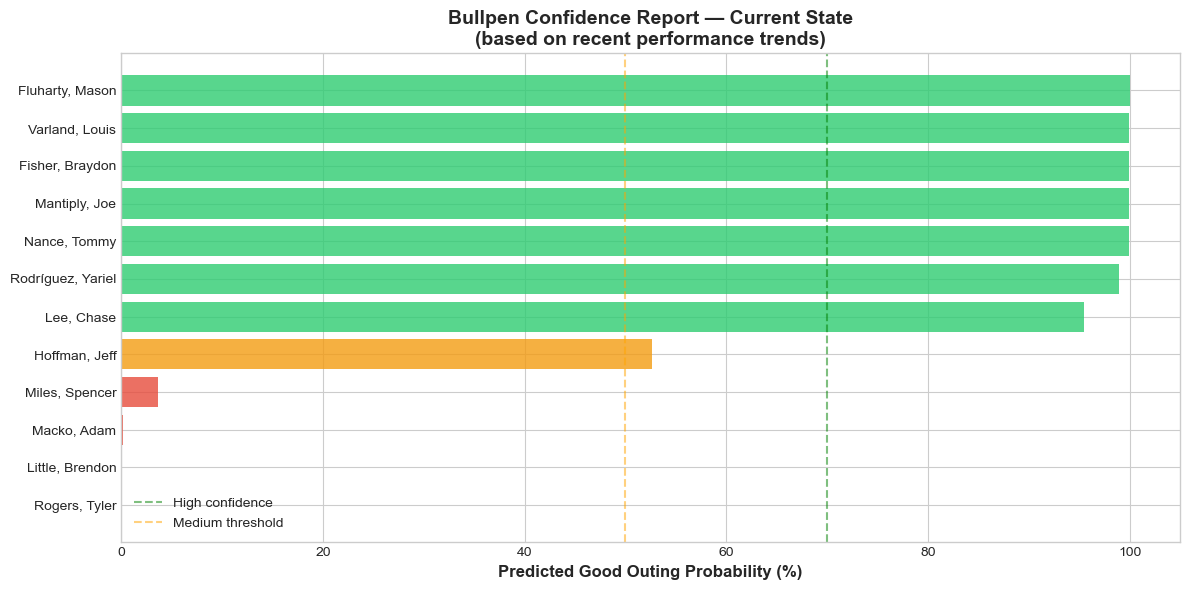

In [9]:
print("=" * 60)
print("  BULLPEN CONFIDENCE REPORT — LATEST DATA")
print("=" * 60)

latest = model_data_copy.sort_values('game_date').groupby('pitcher_name').last().reset_index()
latest = latest[latest['appearance_num'] >= 3]

latest['confidence'] = best_model.predict_proba(latest[FEATURES])[:, 1]
latest = latest.sort_values('confidence', ascending=False)

print("\n{:<20} {:>8} {:>10} {:>12} {:>10}".format(
    'Pitcher', 'Apps', 'Last RV', 'R3 Whiff%', 'Confidence'))
print("-" * 65)

for _, row in latest.iterrows():
    conf = row['confidence']
    if conf >= 0.7:
        signal = "🟢 HIGH"
    elif conf >= 0.5:
        signal = "🟡 MED"
    else:
        signal = "🔴 LOW"

    print("{:<20} {:>8} {:>10} {:>12} {:>10}".format(
        row['pitcher_name'],
        str(int(row['appearance_num'])),
        str(round(row['prev_rv'], 3)),
        str(round(row['rolling3_whiff'], 1)) + '%',
        signal + " (" + str(round(conf * 100, 1)) + "%)"
    ))

fig, ax = plt.subplots(figsize=(12, 6))

latest_sorted = latest.sort_values('confidence', ascending=True)
colors_bar = ['#2ecc71' if c >= 0.7 else '#f39c12' if c >= 0.5 else '#e74c3c' for c in latest_sorted['confidence']]

ax.barh(range(len(latest_sorted)), latest_sorted['confidence'] * 100, color=colors_bar, alpha=0.8)
ax.set_yticks(range(len(latest_sorted)))
ax.set_yticklabels(latest_sorted['pitcher_name'], fontsize=10)
ax.axvline(x=70, color='green', linestyle='--', alpha=0.5, label='High confidence')
ax.axvline(x=50, color='orange', linestyle='--', alpha=0.5, label='Medium threshold')
ax.set_xlabel('Predicted Good Outing Probability (%)', fontsize=12, fontweight='bold')
ax.set_title('Bullpen Confidence Report — Current State\n(based on recent performance trends)',
            fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../visualizations/bullpen_confidence.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()